In [12]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import s3fs
import xarray as xr
import os
import pandas as pd

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

### King discharge

In [14]:
discharge = pd.read_csv('s3://gaia/cjense/data/discharge/ZI_discharge1985-2025.csv', storage_options=storage_options)
discharge['time'] = pd.to_datetime(discharge['time'])
discharge = discharge[discharge['time']>='2000-01-01 00:00:00']
discharge

/var/folders/z2/t78xbk451n74r4q5p4w1zt640000gn/T/ipykernel_32870/2290625297.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  discharge['time'] = pd.to_datetime(discharge['time'])


,time,datenum,Discharge (Gt/yr),Discharge error (1 sigma)
180,2000-01-16,730501.0,8.171720,1.438896
181,2000-02-15,730531.0,8.374499,1.404203
182,2000-03-16,730561.0,8.736176,1.439735
183,2000-04-15,731000.0,9.198614,1.480980
184,2000-05-16,730622.0,9.617354,1.707240
...,...,...,...,...
475,2024-08-16,739480.0,16.682804,2.261361
476,2024-09-15,740000.0,16.421089,2.261361
477,2024-10-16,739541.0,16.296722,2.261361
478,2024-11-15,740000.0,16.303458,2.261361


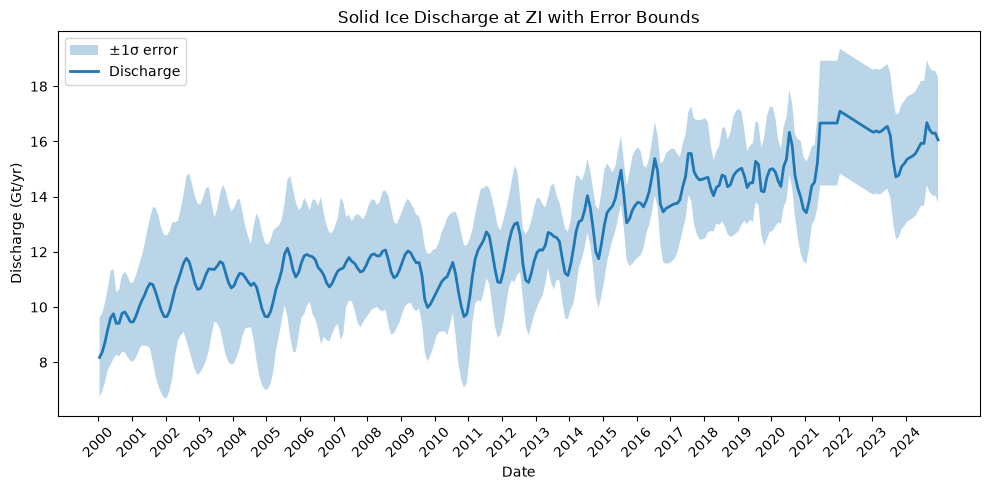

In [16]:
plt.subplots(figsize=(10,5))

# Remove NaN values
discharge_clean = discharge.dropna(subset=['Discharge (Gt/yr)', 'Discharge error (1 sigma)'])

years = pd.date_range(
    discharge_clean['time'].min().replace(month=1, day=1),
    discharge_clean['time'].max(),
    freq='YS'
)

# Plot with shaded error bars
plt.fill_between(
    discharge_clean['time'],
    discharge_clean['Discharge (Gt/yr)'] - discharge_clean['Discharge error (1 sigma)'],
    discharge_clean['Discharge (Gt/yr)'] + discharge_clean['Discharge error (1 sigma)'],
    alpha=0.3,
    label='±1σ error'
)
plt.plot(discharge_clean['time'], discharge_clean['Discharge (Gt/yr)'], linewidth=2, label='Discharge')

plt.xticks(years, years.strftime('%Y'), rotation=45)
plt.ylabel('Discharge (Gt/yr)')
plt.xlabel('Date')
plt.title('Solid Ice Discharge at ZI with Error Bounds')
plt.legend()
plt.tight_layout()
plt.savefig('figures/discharge_ZI_King_error.png', dpi=300)
plt.show()

In [17]:
discharge = discharge.set_index('time')
discharge_daily = discharge.resample('D').interpolate(method='linear')
discharge_daily = discharge_daily.reset_index()

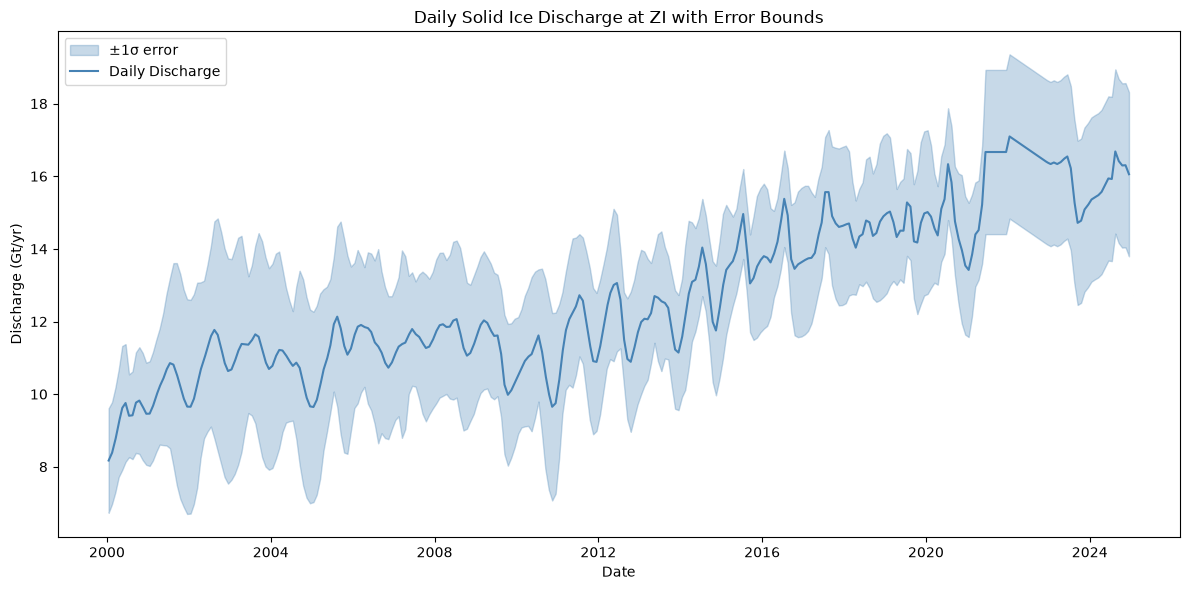

In [19]:
plt.figure(figsize=(12, 6))

# Remove NaN values
discharge_clean = discharge_daily.dropna(subset=['Discharge (Gt/yr)', 'Discharge error (1 sigma)'])

# Plot with shaded error bars for daily data
plt.fill_between(
    discharge_clean['time'],
    discharge_clean['Discharge (Gt/yr)'] - discharge_clean['Discharge error (1 sigma)'],
    discharge_clean['Discharge (Gt/yr)'] + discharge_clean['Discharge error (1 sigma)'],
    alpha=0.3,
    label='±1σ error',
    color='steelblue'
)
plt.plot(discharge_clean['time'], discharge_clean['Discharge (Gt/yr)'], linewidth=1.5, label='Daily Discharge', color='steelblue')

plt.ylabel('Discharge (Gt/yr)')
plt.xlabel('Date')
plt.title('Daily Solid Ice Discharge at ZI with Error Bounds')
plt.legend()
plt.tight_layout()
plt.savefig('figures/discharge_ZI_King_daily_error.png', dpi=300)
plt.show()

In [23]:
discharge.to_parquet('s3://gaia/cjense/data/discharge/discharge_monthly_ZI_King.parquet', storage_options=storage_options)
discharge_daily.to_parquet('s3://gaia/cjense/data/discharge/discharge_daily_ZI_King.parquet', storage_options=storage_options)

### Mankoff discharge

In [57]:
dis = pd.read_csv('/Users/cjense/Downloads/dataverse_files/sector_D.csv')
dis['Date'] = pd.to_datetime(dis['Date'])

In [62]:
disZI = dis[['Date', 'ZACHARIAE_ISSTROM']]
disZI = disZI.loc[(disZI['Date'] > '2000-01-01') & (disZI['Date'] <= '2025-12-31')]
disZI

,Date,ZACHARIAE_ISSTROM
102,2000-02-15,10.143400
103,2000-03-15,10.315785
104,2000-04-15,10.500049
105,2000-05-15,10.678360
106,2000-06-15,10.862606
...,...,...
2959,2025-11-12,17.465826
2960,2025-11-24,17.243470
2961,2025-12-06,17.397650
2962,2025-12-18,17.406412


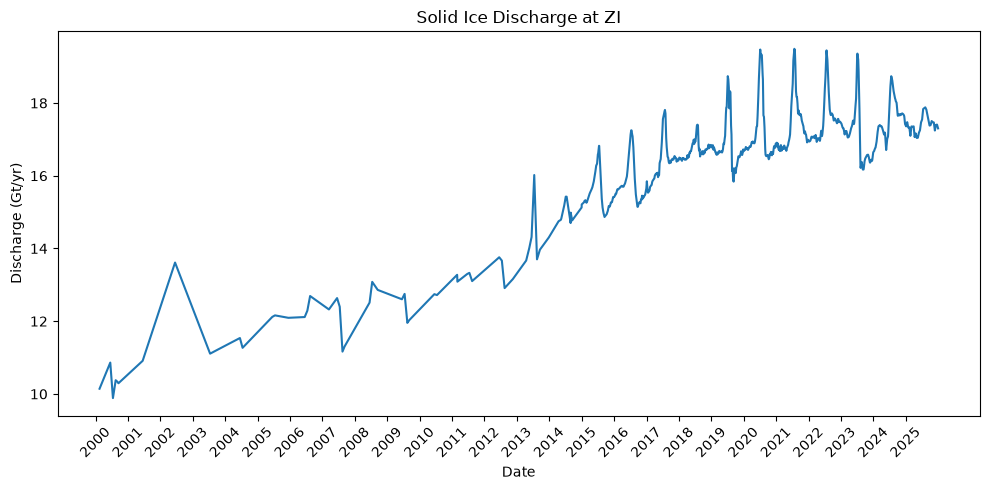

In [63]:
plt.subplots(figsize=(10,5))

plt.plot(disZI['Date'], disZI['ZACHARIAE_ISSTROM'])

years = pd.date_range(
    disZI['Date'].min().replace(month=1, day=1),
    disZI['Date'].max(),
    freq='YS'
)

plt.xticks(years, years.strftime('%Y'), rotation=45)
plt.ylabel('Discharge (Gt/yr)')
plt.xlabel('Date')
plt.title('Solid Ice Discharge at ZI')
plt.tight_layout()
plt.savefig('figures/discharge_ZI.png', dpi=300)
plt.show()

In [61]:
dis79N = dis[['Date', 'NIOGHALVFJERDSFJORDEN']]
dis79N = dis79N.loc[(dis79N['Date'] > '2000-01-01') & (dis79N['Date'] <= '2025-12-31')]
dis79N

,Date,NIOGHALVFJERDSFJORDEN
102,2000-02-15,12.188143
103,2000-03-15,12.299239
104,2000-04-15,12.417985
105,2000-05-15,12.532892
106,2000-06-15,12.651617
...,...,...
2959,2025-11-12,13.244141
2960,2025-11-24,13.144099
2961,2025-12-06,13.211903
2962,2025-12-18,13.250596


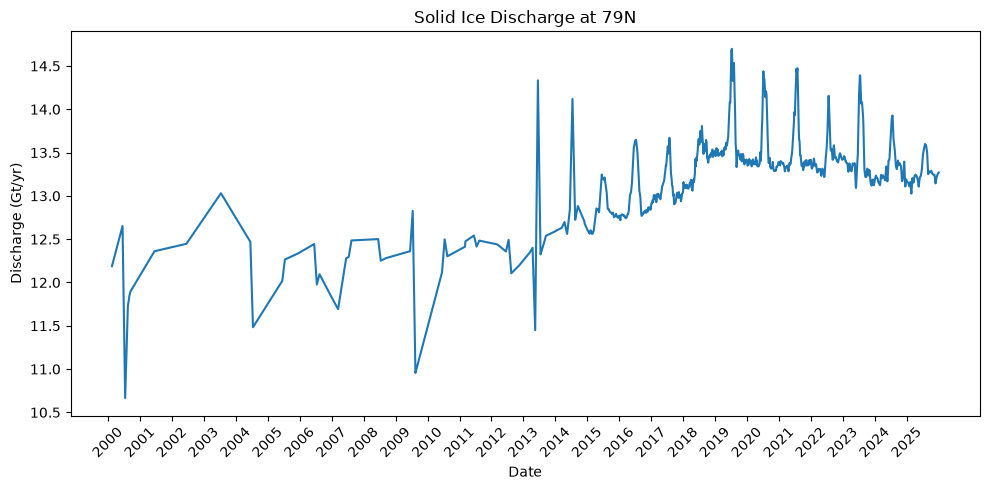

In [ ]:
plt.subplots(figsize=(10,5))
plt.plot(dis79N['Date'], dis79N['NIOGHALVFJERDSFJORDEN'])

years = pd.date_range(
    dis79N['Date'].min().replace(month=1, day=1),
    dis79N['Date'].max(),
    freq='YS'
)

plt.xticks(years, years.strftime('%Y'), rotation=45)
plt.ylabel('Discharge (Gt/yr)')
plt.xlabel('Date')
plt.title('Solid Ice Discharge at 79N')
plt.tight_layout()
plt.savefig(fname='figures/discharge_79N.png', dpi=300)
plt.show()

In [66]:
dis79N.to_parquet('s3://gaia/cjense/data/discharge/discharge_79N.parquet', storage_options=storage_options)
disZI.to_parquet('s3://gaia/cjense/data/discharge/discharge_ZI.parquet', storage_options=storage_options)